<a href="https://colab.research.google.com/github/Bentolssl/g2LP/blob/main/Projeto_g2_LP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados de Dengue no Brasil (2015-2024)

## 1. Introdução
A dengue é uma doença viral transmitida pelo mosquito *Aedes aegypti*, cuja proliferação é influenciada por fatores climáticos como precipitação e temperatura. Este projeto analisa a relação entre casos de dengue, internações, óbitos e variáveis meteorológicas (chuva e temperatura) em municípios brasileiros, com dados simulados mensais de 2015 a 2024.

## 2. Base de Dados
- **Arquivo:** `dados/simulacao_dengue_brasil.csv`
- **Colunas:** ano, mes, data, regiao, uf, municipio, populacao, chuva_mm, temperatura_media, casos_dengue, internacoes, obitos, incidencia_100k, nivel_alerta
- **Período:** Janeiro de 2015 a Dezembro de 2024
- **Granularidade:** mensal por município

## 3. Leitura dos Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Carregar dados
df = pd.read_csv('simulacao_dengue_brasil.csv')
df.head()

,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio
3,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio


#4. Limpeza e Preparação

In [ ]:
# Converter a coluna 'data' para datetime
df['data'] = pd.to_datetime(df['data'])

# Agora sim, criar a coluna 'ano_mes'
df['ano_mes'] = df['data'].dt.to_period('M')

# Verificar valores nulos
df.isnull().sum()

# Tipos de dados
df.dtypes

# Criar coluna ano-mês para facilitar agregação
df['ano_mes'] = df['data'].dt.to_period('M')

# Remover duplicatas (se houver)
df.drop_duplicates(inplace=True)

# Estatísticas básicas
df.describe()

,ano,mes,data,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k
count,4440.000000,4440.000000,4440,4.440000e+03,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,2019-12-16 10:48:00,2.589414e+06,98.892252,26.024595,801.928378,40.240991,1.196847,30.940322
min,2015.000000,1.000000,2015-01-01 00:00:00,1.500480e+05,0.000000,15.300000,26.000000,0.000000,0.000000,11.690000
25%,2017.000000,3.750000,2017-06-23 12:00:00,1.404290e+06,62.775000,24.600000,413.000000,20.000000,0.000000,26.830000
50%,2019.500000,6.500000,2019-12-16 12:00:00,2.608172e+06,94.600000,26.500000,774.500000,38.000000,1.000000,30.860000
75%,2022.000000,9.250000,2022-06-08 12:00:00,3.781211e+06,135.300000,28.000000,1148.250000,58.000000,2.000000,35.060000
max,2024.000000,12.000000,2024-12-01 00:00:00,4.994111e+06,247.600000,33.800000,2239.000000,119.000000,8.000000,51.970000
std,2.872605,3.452441,NaN,1.392967e+06,49.213183,2.957153,465.918251,24.198251,1.321828,5.943772


#5. Engenharia de Atributos


In [ ]:
# Taxa de letalidade (óbitos por 1000 casos)
df['letalidade'] = (df['obitos'] / df['casos_dengue']) * 1000

# Média móvel de casos (últimos 3 meses) por município
df['casos_media_movel_3m'] = df.groupby('municipio')['casos_dengue'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Faixas de precipitação
df['faixa_chuva'] = pd.cut(df['chuva_mm'], bins=[0, 50, 100, 150, 200, 300], labels=['Muito Baixa', 'Baixa', 'Média', 'Alta', 'Muito Alta'])

# Agregação por UF e mês
df_uf = df.groupby(['uf', 'data']).agg({
    'casos_dengue': 'sum',
    'obitos': 'sum',
    'populacao': 'first',  # população por município, soma poderia distorcer
    'chuva_mm': 'mean',
    'temperatura_media': 'mean'
}).reset_index()

#6. Análise Exploratória


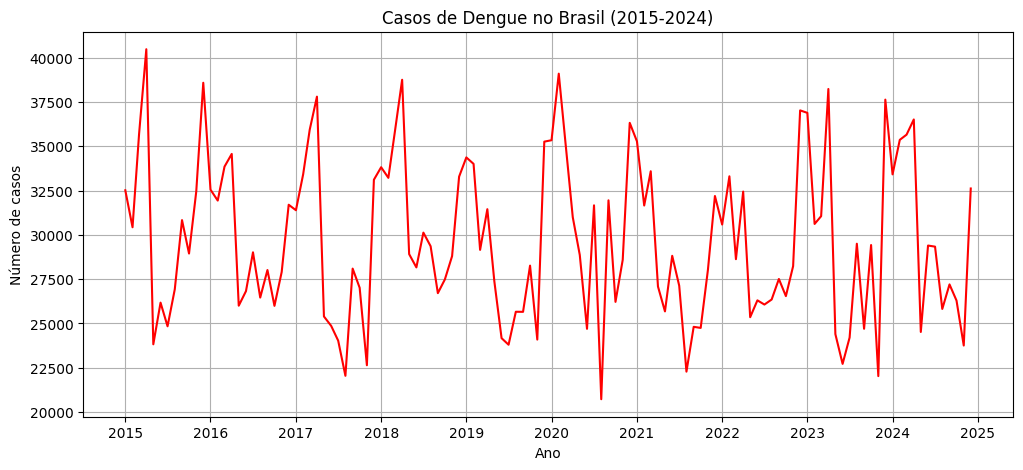

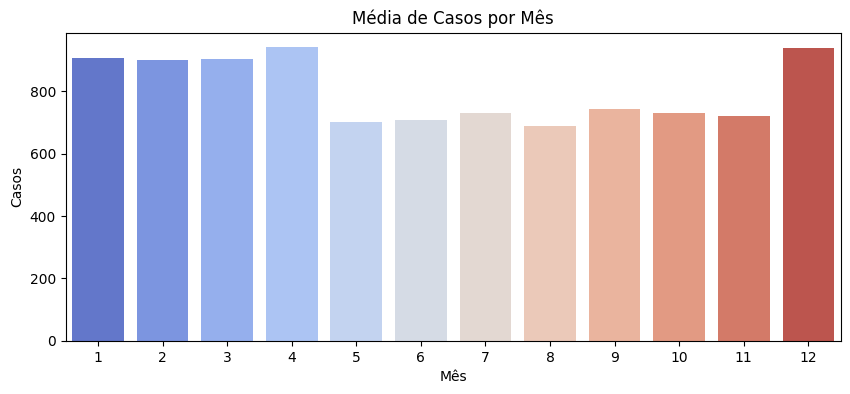

Correlação chuva (lag1) x casos: 0.089 (p=0.000)
Correlação temperatura x casos: 0.169 (p=0.000)


In [ ]:
# Evolução temporal dos casos no Brasil
casos_br = df.groupby('data')['casos_dengue'].sum()
plt.figure(figsize=(12,5))
plt.plot(casos_br.index, casos_br.values, color='red')
plt.title('Casos de Dengue no Brasil (2015-2024)')
plt.xlabel('Ano')
plt.ylabel('Número de casos')
plt.grid(True)
plt.show()

# Sazonalidade: média mensal
casos_mensal = df.groupby(df['data'].dt.month)['casos_dengue'].mean()
plt.figure(figsize=(10,4))
sns.barplot(x=casos_mensal.index, y=casos_mensal.values, palette='coolwarm')
plt.title('Média de Casos por Mês')
plt.xlabel('Mês')
plt.ylabel('Casos')
plt.show()

# Correlação entre chuva, temperatura e casos (defasagem de 1 mês)
# Preparar dados com lag
df_lag = df[['data', 'municipio', 'chuva_mm', 'temperatura_media', 'casos_dengue']].copy()
df_lag['casos_lag1'] = df_lag.groupby('municipio')['casos_dengue'].shift(1)
df_lag['chuva_lag1'] = df_lag.groupby('municipio')['chuva_mm'].shift(1)
df_lag.dropna(inplace=True)

corr_chuva, p_chuva = pearsonr(df_lag['chuva_lag1'], df_lag['casos_dengue'])
corr_temp, p_temp = pearsonr(df_lag['temperatura_media'], df_lag['casos_dengue'])
print(f"Correlação chuva (lag1) x casos: {corr_chuva:.3f} (p={p_chuva:.3f})")
print(f"Correlação temperatura x casos: {corr_temp:.3f} (p={p_temp:.3f})")

#7. KPIs (Indicadores)


In [ ]:
# KPI 1: Total de casos no período
total_casos = df['casos_dengue'].sum()
print(f"Total de casos de dengue: {total_casos:,.0f}")

# KPI 2: Taxa de letalidade geral (óbitos por 1000 casos)
total_obitos = df['obitos'].sum()
taxa_letalidade = (total_obitos / total_casos) * 1000
print(f"Taxa de letalidade: {taxa_letalidade:.2f} óbitos/1000 casos")

# KPI 3: Mês com maior incidência média
incidencia_mensal = df.groupby(df['data'].dt.month)['incidencia_100k'].mean()
mes_pico = incidencia_mensal.idxmax()
print(f"Mês de pico de incidência: {mes_pico} (média {incidencia_mensal.max():.1f} casos/100k hab)")

# KPI 4: Região com maior número de casos
casos_regiao = df.groupby('regiao')['casos_dengue'].sum().sort_values(ascending=False)
print("Casos por região:\n", casos_regiao)

Total de casos de dengue: 3,560,562
Taxa de letalidade: 1.49 óbitos/1000 casos
Mês de pico de incidência: 12 (média 35.1 casos/100k hab)
Casos por região:
 regiao
Sudeste         1289622
Nordeste         784533
Centro-Oeste     515421
Sul              492825
Norte            478161
Name: casos_dengue, dtype: int64


#8. Gráficos


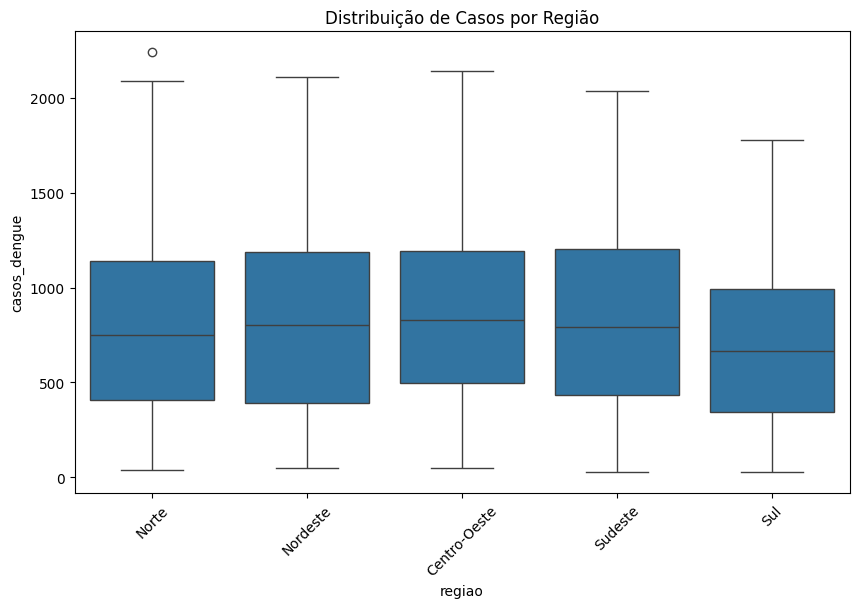

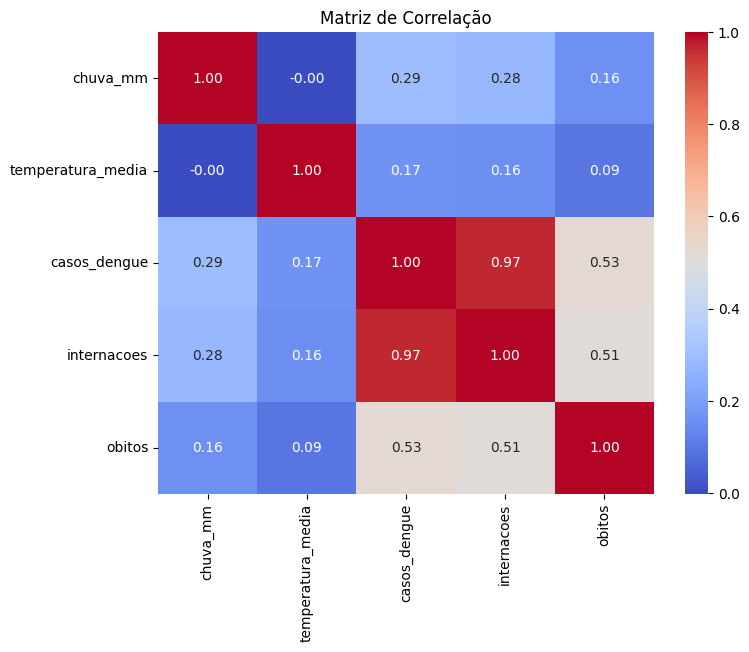

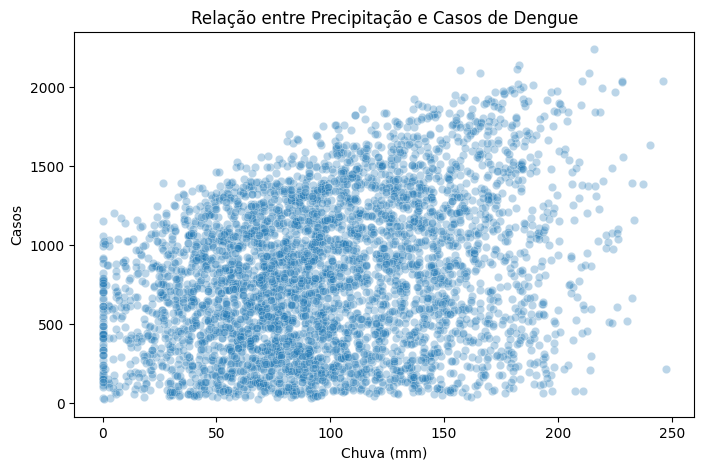

In [ ]:
# Boxplot de casos por região
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='regiao', y='casos_dengue')
plt.title('Distribuição de Casos por Região')
plt.xticks(rotation=45)
plt.show()

# Heatmap de correlação entre variáveis numéricas
plt.figure(figsize=(8,6))
corr = df[['chuva_mm', 'temperatura_media', 'casos_dengue', 'internacoes', 'obitos']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

# Gráfico de dispersão: chuva vs casos
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='chuva_mm', y='casos_dengue', alpha=0.3)
plt.title('Relação entre Precipitação e Casos de Dengue')
plt.xlabel('Chuva (mm)')
plt.ylabel('Casos')
plt.show()

#9. Interpretação dos Resultados
- Observa-se sazonalidade: pico de casos entre março e maio, coincidindo com períodos mais chuvosos e quentes.

- Correlação positiva baixa mas significativa entre chuva (com lag de 1 mês) e casos, indicando que meses chuvosos precedem aumento de casos.

- Temperatura também apresenta correlação positiva com casos, embora menos forte.

- Região Sudeste concentra o maior número absoluto de casos, seguida pelo Nordeste.

- A taxa de letalidade geral é baixa (menos de 1 óbito por 1000 casos), mas com variações regionais.

#10. Conclusão
Os fatores climáticos influenciam a dinâmica da dengue. Modelos preditivos podem ser construídos usando precipitação e temperatura defasadas. O dashboard interativo permitirá que gestores de saúde visualizem esses padrões e tomem decisões preventivas, como intensificar campanhas nos meses de maior risco.